## 0. Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from zipfile import ZipFile
import os
import urllib.request
import math

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf

pd.set_option("display.max_rows", 500)       
pd.set_option("display.max_columns", None)  
pd.set_option("display.width", 1200)          
pd.set_option("display.max_colwidth", None)

## 1. Setup

In [2]:
# ------------------------------
# Project directory structure
# ------------------------------
# Define base working directory and create folders used to store
# downloaded datasets, extracted raw data, and outputs.

base_path = os.getcwd()
data_path = os.path.join(base_path, "data")
os.makedirs(data_path, exist_ok=True)

datapack_path = os.path.join(data_path, "pack")   # Compressed datasets
dataraw_path = os.path.join(data_path, "raw")     # Extracted CSV files
output_path = os.path.join(data_path, "output")   # Folder for outputs
os.makedirs(datapack_path, exist_ok=True)
os.makedirs(dataraw_path, exist_ok=True)
os.makedirs(output_path, exist_ok=True)        

# ------------------------------
# Reproducibility configuration
# ------------------------------
# Fix random seeds to ensure that experiments are reproducible.
# This affects NumPy and PyTorch operations.

SEED = 42
np.random.seed(SEED)                  # NumPy random seed
torch.manual_seed(SEED)               # PyTorch CPU seed

# Ensure deterministic behaviour in CUDA operations
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ------------------------------
# Device configuration
# ------------------------------
# Select GPU if available, otherwise fall back to CPU.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ------------------------------
# Visualization style
# ------------------------------
# Set a consistent plotting style for all figures in the notebook.

sns.set(style="whitegrid")


# ------------------------------
# Environment information
# ------------------------------
# Display relevant runtime information for reproducibility.

print(f"PyTorch Version: {torch.__version__}")
print(f"Device: {device}")
print(f"CUDA Version (Torch): {torch.version.cuda if torch.cuda.is_available() else 'None'}")

PyTorch Version: 2.2.2
Device: cuda
CUDA Version (Torch): 12.1


## 2. Data

### 2.1 Download

In [3]:
# ---------------------------------
# Jena Climate dataset source
# ---------------------------------
# The dataset is publicly available from the TensorFlow repository.
# It contains meteorological observations collected in Jena, Germany,
# between 2009 and 2016.

uri = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
zip_filename = os.path.join(datapack_path, "jena_climate_2009_2016.csv.zip")


# ---------------------------------
# Download dataset if not available
# ---------------------------------
# The file is downloaded only if it does not already exist locally.

if not os.path.exists(zip_filename):
    print("Downloading Jena Climate dataset...")
    urllib.request.urlretrieve(uri, zip_filename)
    print("Download completed!")


# ---------------------------------
# Extract compressed dataset
# ---------------------------------
# The CSV file is extracted to the raw data directory.

with ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(dataraw_path)


# ---------------------------------
# Define CSV file path
# ---------------------------------
# Path to the extracted dataset used in the next steps.

csv_path = os.path.join(dataraw_path, "jena_climate_2009_2016.csv")
print(f"CSV path: {csv_path}")

CSV path: c:\Users\tomfp\Desktop\Tomás\Estudos\ISCTE\Pós-Graduação\Inteligência Artificial - ISCTE\Tópicos Avançados de Aprendizagem Profunda\TSM\projeto\data\raw\jena_climate_2009_2016.csv


### 2.2 Load

In [4]:
### 2.2 Data Loading

# ---------------------------------
# Selected variables for the project
# ---------------------------------
# According to the assignment guidelines, only a subset of the original
# Jena Climate variables should be used. These variables represent
# relevant meteorological measurements without including variables
# that are near-deterministic transformations of the target.

cols_dict = {
 'Date Time': {'description': 'Measurement timestamp',
               'unit': None,
               'limit': None,
               'title': 'Date Time',
               'color': 'black'},

 'T (degC)': {'description': 'Air temperature',
              'unit': '°C',
              'limit': [-50, 50],
              'title': 'Temperature',
              'color': 'orange'},

 'p (mbar)': {'description': 'Atmospheric pressure',
              'unit': 'mbar',
              'limit': [800, 1100],
              'title': 'Pressure',
              'color': 'blue'},

 'rh (%)': {'description': 'Relative humidity',
            'unit': '%',
            'limit': [0, 100],
            'title': 'Relative Humidity',
            'color': 'purple'},

 'wv (m/s)': {'description': 'Mean wind speed',
              'unit': 'm/s',
              'limit': [0, 60],
              'title': 'Wind speed',
              'color': 'cyan'},

 'max. wv (m/s)': {'description': 'Maximum wind speed',
                   'unit': 'm/s',
                   'limit': [0, 100],
                   'title': 'Maximum wind speed',
                   'color': 'pink'},

 'wd (deg)': {'description': 'Wind direction',
              'unit': 'degrees',
              'limit': [0, 360],
              'title': 'Wind direction in degrees',
              'color': 'gray'}
}


# Key used to reference the timestamp column
date_time_key = "Date Time"


# ---------------------------------
# DataFrame storage dictionary
# ---------------------------------
# This dictionary allows us to store intermediate versions of the dataset
# during the preprocessing pipeline (e.g., raw, cleaned, resampled).

df_dict = {}

def update_df_dict(df_dict, name, df):
    df_dict[name] = df
    return df_dict


# ---------------------------------
# Load dataset from CSV
# ---------------------------------

# The dataset is loaded and only the required columns defined in
# cols_dict are retained.

df = pd.read_csv(csv_path)
new_df = df[list(cols_dict.keys())].copy()
df = new_df


# ---------------------------------
# Data Preparation
# ---------------------------------

# Convert the Date Time column to pandas datetime format
# to enable proper time series manipulation.
df["Date Time"] = pd.to_datetime(df["Date Time"], format="%d.%m.%Y %H:%M:%S")
df = df.sort_values(by=date_time_key).reset_index(drop=True)


# Remove invalid final observation
# The dataset contains a single observation from 2017,
# which lies outside the main data range (2009–2016).
# It is removed to maintain temporal consistency.
df = df.iloc[:-1].copy()

# Remove duplicate timestamps
df = df.drop_duplicates(subset=[date_time_key], keep='first')

### 2.3 Sanity Checks

In [5]:
### 2.3 Data Sanity Checks

# ---------------------------------------------------
# Basic data quality verification
# ---------------------------------------------------
# This function performs a set of sanity checks to ensure that the
# dataset is consistent and suitable for time series modelling.
# The checks include:
#   - dataset dimensions
#   - column availability
#   - data types
#   - timestamp validity and ordering
#   - duplicate timestamps
#   - missing values
#   - sampling interval consistency

def sanity_checks(df, cols_dict, date_time_key="Date Time"):
    
    print("=== SANITY CHECKS ===\n")
    
    # ---------------------------------
    # 1. Dataset shape
    # ---------------------------------
    # Verify the number of rows and columns in the dataset.
    
    print("1. Dataset shape")
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")
    
    
    # ---------------------------------
    # 2. Column availability
    # ---------------------------------
    # Ensure that all required variables specified in cols_dict
    # are present in the dataset.
    
    print("2. Column availability")
    missing_cols = [c for c in cols_dict.keys() if c not in df.columns]
    
    if missing_cols:
        print("Missing columns:", missing_cols)
    else:
        print("All required columns are present")
        
    print()
    
    
    # ---------------------------------
    # 3. Data type verification
    # ---------------------------------
    # Display the data types of all columns to verify that
    # numeric variables and timestamps are correctly interpreted.
    
    print("3. Data types")
    display(df.dtypes)
    
    
    # ---------------------------------
    # 4. Timestamp validation
    # ---------------------------------
    # Ensure that the Date Time column is properly formatted
    # and that the dataset is chronologically ordered.
    
    print("\n4. Date Time checks")
    
    if not pd.api.types.is_datetime64_any_dtype(df[date_time_key]):
        print("Date Time column is not datetime")
    else:
        print("Date Time column is datetime")
    
    
    # Check chronological ordering
    if not df[date_time_key].is_monotonic_increasing:
        print("Date Time is not sorted — sorting applied")
        df.sort_values(date_time_key, inplace=True)
        df.reset_index(drop=True, inplace=True)
    else:
        print("Date Time is sorted")
    
    
    # ---------------------------------
    # Duplicate timestamp detection
    # ---------------------------------
    # Duplicate timestamps could indicate corrupted observations
    # or measurement issues.
    
    dup_count = df[date_time_key].duplicated().sum()
    print(f"Duplicate timestamps: {dup_count}")
    
    
    # ---------------------------------
    # 5. Missing values inspection
    # ---------------------------------
    # Identify missing values that may require imputation
    # or removal before modelling.
    
    print("\n5. Missing values per column")
    
    na_counts = df.isna().sum()
    
    display(
        na_counts[na_counts > 0]
        if na_counts.sum() > 0
        else "No missing values"
    )
    
    
    # ---------------------------------
    # 6. Sampling interval consistency
    # ---------------------------------
    # Verify the time difference between consecutive observations.
    # The original dataset should have a regular 10-minute interval.
    
    print("\n6. Sampling interval (minutes)")
    
    deltas = df[date_time_key].diff().dropna()
    
    display(deltas.value_counts())
    
    
    print("\n=== END SANITY CHECKS ===")
    
    return df

In [6]:
# Run sanity checks
df = sanity_checks(df, cols_dict, date_time_key)

=== SANITY CHECKS ===

1. Dataset shape
Rows: 420223, Columns: 7

2. Column availability
All required columns are present

3. Data types


Date Time        datetime64[us]
T (degC)                float64
p (mbar)                float64
rh (%)                  float64
wv (m/s)                float64
max. wv (m/s)           float64
wd (deg)                float64
dtype: object


4. Date Time checks
Date Time column is datetime
Date Time is sorted
Duplicate timestamps: 0

5. Missing values per column


'No missing values'


6. Sampling interval (minutes)


Date Time
0 days 00:10:00    420217
0 days 00:20:00         2
0 days 00:30:00         1
0 days 16:00:00         1
3 days 02:20:00         1
Name: count, dtype: int64


=== END SANITY CHECKS ===


In [7]:
def get_irregular_intervals(df, date_time_col="Date Time", expected_minutes=10):
    """
    Print rows in a time series DataFrame where the interval between
    consecutive timestamps is different from the expected interval.

    Parameters:
        df (pd.DataFrame): Input DataFrame with a datetime column.
        date_time_col (str): Name of the datetime column.
        expected_minutes (int): Expected time interval in minutes.
    """
    expected_delta = pd.Timedelta(minutes=expected_minutes)
    
    df_check = df.copy()
    df_check["prev_time"] = df_check[date_time_col].shift(1)
    df_check["delta"] = df_check[date_time_col] - df_check["prev_time"]
    
    irregular_rows = df_check[df_check["delta"] != expected_delta].sort_values("delta")
    
    print(f"Total irregular intervals: {len(irregular_rows)}\n")
    display(irregular_rows)


get_irregular_intervals(df, date_time_col="Date Time", expected_minutes=10)

Total irregular intervals: 6



,Date Time,T (degC),p (mbar),rh (%),wv (m/s),max. wv (m/s),wd (deg),prev_time,delta
230019,2013-05-16 09:10:00,16.85,973.31,77.70,2.66,4.68,46.6,2013-05-16 08:50:00,0 days 00:20:00
293556,2014-07-30 08:20:00,20.06,981.58,89.40,0.93,1.36,78.4,2014-07-30 08:00:00,0 days 00:20:00
40378,2009-10-08 10:10:00,20.52,983.60,61.97,6.53,8.93,242.2,2009-10-08 09:40:00,0 days 00:30:00
301673,2014-09-25 09:00:00,12.34,989.73,78.30,2.63,4.34,240.7,2014-09-24 17:00:00,0 days 16:00:00
411267,2016-10-28 12:50:00,12.44,1003.87,74.10,1.52,4.22,283.9,2016-10-25 10:30:00,3 days 02:20:00
0,2009-01-01 00:10:00,-8.02,996.52,93.30,1.03,1.75,152.3,NaT,NaT


In [8]:
# ---------------------------------
# Data Storage
# ---------------------------------

# Store dataset version before further preprocessing
df_dict["df_unclean"] = df

In [9]:
# Print all DataFrame names stored in df_dict
print("DataFrames in df_dict:")
for name in df_dict.keys():
    print("-", name)

DataFrames in df_dict:
- df_unclean


## 3. Pre-analysis

### 3.1 Clean

In [10]:
def clean_impossible_outliers(df, cols_dict, date_time_key="Date Time"):
    """
    Limpa valores impossíveis de acordo com os limites definidos em cols_dict.
    Valores fora dos limites são substituídos pela média dos valores válidos da coluna.

    Retorna:
    - df_clean: DataFrame limpo
    - impossible_values: dicionário com {(row_index, column_name): valor_impossível}
    """
    df_clean = df.copy()
    impossible_values = {}

    for col, info in cols_dict.items():
        if col == date_time_key:
            continue  # ignorar coluna de data
        
        limit = info.get("limit")
        if limit is None:
            continue  # sem limite definido, pular
        
        lower, upper = limit
        # Máscara de valores fora do limite
        mask_impossible = (df_clean[col] < lower) | (df_clean[col] > upper)
        
        # Registrar valores impossíveis
        for idx in df_clean.index[mask_impossible]:
            impossible_values[(idx, col)] = df_clean.at[idx, col]
        
        # Substituir pelos valores médios válidos
        mean_valid = df_clean.loc[~mask_impossible, col].mean()
        df_clean.loc[mask_impossible, col] = mean_valid

    print(f"Total de valores impossíveis corrigidos: {len(impossible_values)}")
    return df_clean, impossible_values

df_clean, impossible_values = clean_impossible_outliers(df, cols_dict)


Total de valores impossíveis corrigidos: 38


In [11]:
def clean_unlikely_outliers(df, cols_dict, window=3, date_time_key="Date Time"):
    """
    Limpa outliers improváveis (dentro dos limites físicos, mas estatisticamente extremos)
    usando IQR e substituindo pela mediana local.

    Parâmetros:
    - df: DataFrame com os dados
    - cols_dict: dicionário com limites e metadados das colunas
    - window: tamanho da janela para calcular a mediana local (número de linhas antes/depois)
    - date_time_key: coluna de datas

    Retorna:
    - df_clean: DataFrame com valores improváveis substituídos
    - outlier_values: dicionário {(row_index, column_name): valor_original}
    """
    df_clean = df.copy()
    outlier_values = {}

    for col, info in cols_dict.items():
        if col == date_time_key:
            continue
        
        # Calcular IQR
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5*IQR
        upper = Q3 + 1.5*IQR
        
        mask_outlier = (df_clean[col] < lower) | (df_clean[col] > upper)
        
        # Registrar valores
        for idx in df_clean.index[mask_outlier]:
            outlier_values[(idx, col)] = df_clean.at[idx, col]
        
        # Substituir pelos valores medianos da janela local
        df_clean[col] = df_clean[col].mask(
            mask_outlier,
            df_clean[col].rolling(window=window, center=True, min_periods=1).median()
        )
    
    print(f"Total de outliers improváveis corrigidos: {len(outlier_values)}")
    return df_clean, outlier_values


df_clean, unlikely_outliers = clean_unlikely_outliers(df_clean, cols_dict, window=5)

df_dict["df_clean"] = df_clean

Total de outliers improváveis corrigidos: 35649


### 3.2 Variation — Temporal Aggregation

In [12]:
def resample_time_series_average(df, freq, date_time_key="Date Time"):
    """
    Reamostra uma série temporal usando média.

    Parâmetros:
    - df: DataFrame original
    - freq: string de frequência pandas ('D', 'M', 'Y')
    - date_time_key: coluna datetime

    Retorna:
    - df_resampled: DataFrame reamostrado
    """
    df_resampled = (
        df
        .set_index(date_time_key)
        .resample(freq)
        .mean(numeric_only=True)
        .reset_index()
    )
    return df_resampled

def resample_time_series_median(df, freq, date_time_key="Date Time"):
    """
    Reamostra uma série temporal usando mediana.

    Parâmetros:
    - df: DataFrame original
    - freq: string de frequência pandas ('D', 'ME', 'YE')
    - date_time_key: coluna datetime

    Retorna:
    - df_resampled: DataFrame reamostrado
    """
    df_resampled = (
        df
        .set_index(date_time_key)
        .resample(freq)
        .median(numeric_only=True)
        .reset_index()
    )
    return df_resampled

## Average ----------------------------------------------
# Daily
df_day_average = resample_time_series_average(df, freq="D")
df_clean_day_average = resample_time_series_average(df_clean, freq="D")

df_dict["df_day_average"] = df_day_average
df_dict["df_clean_day_average"] = df_clean_day_average

# Monthly
df_month_average = resample_time_series_average(df, freq="ME")
df_clean_month_average = resample_time_series_average(df_clean, freq="ME")

df_dict["df_month_average"] = df_month_average
df_dict["df_clean_month_average"] = df_clean_month_average

# Yearly
df_year_average = resample_time_series_average(df, freq="YE")
df_clean_year_average = resample_time_series_average(df_clean, freq="YE")

df_dict["df_year_average"] = df_year_average
df_dict["df_clean_year_average"] = df_clean_year_average


## Median ----------------------------------------------
# Daily
df_day_median = resample_time_series_median(df, freq="D")
df_clean_day_median = resample_time_series_median(df_clean, freq="D")

df_dict["df_day_median"] = df_day_median
df_dict["df_clean_day_median"] = df_clean_day_median

# Monthly
df_month_median = resample_time_series_median(df, freq="ME")
df_clean_month_median = resample_time_series_median(df_clean, freq="ME")

df_dict["df_month_median"] = df_month_median
df_dict["df_clean_month_median"] = df_clean_month_median

# Yearly
df_year_median = resample_time_series_median(df, freq="YE")
df_clean_year_median = resample_time_series_median(df_clean, freq="YE")

df_dict["df_year_median"] = df_year_median
df_dict["df_clean_year_median"] = df_clean_year_median

### 3.3 Visualization

In [13]:
def show_raw_visualization(df, cols_dict, date_time_key="Date Time", figure_title=None):
    """
    Visualização rápida das séries temporais do DataFrame.
    
    Parâmetros:
    - df: DataFrame com os dados
    - cols_dict: dicionário com metadados das colunas (title, color, limits)
    - date_time_key: coluna de datas
    - figure_title: título geral da figura (ex: "Raw Data", "Cleaned Data")
    """
    feature_keys = [col for col in cols_dict if col != date_time_key]
    
    n_plots = len(feature_keys)
    ncols = 2
    nrows = math.ceil(n_plots / ncols)
    
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(15, nrows * 4),
        dpi=80
    )
    axes = axes.flatten()
    
    for i, key in enumerate(feature_keys):
        col_info = cols_dict[key]
        ax = axes[i]
        df.plot(
            x=date_time_key,
            y=key,
            ax=ax,
            color=col_info.get("color", "black"),
            title=f"{col_info.get('title', key)} ({key})",
            rot=25
        )
        ax.legend([col_info.get("title", key)])
    
    # Remover eixos extras
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    # Título geral
    if figure_title is not None:
        fig.suptitle(figure_title, fontsize=16, y=1.02)
    
    plt.tight_layout()
    plt.show()

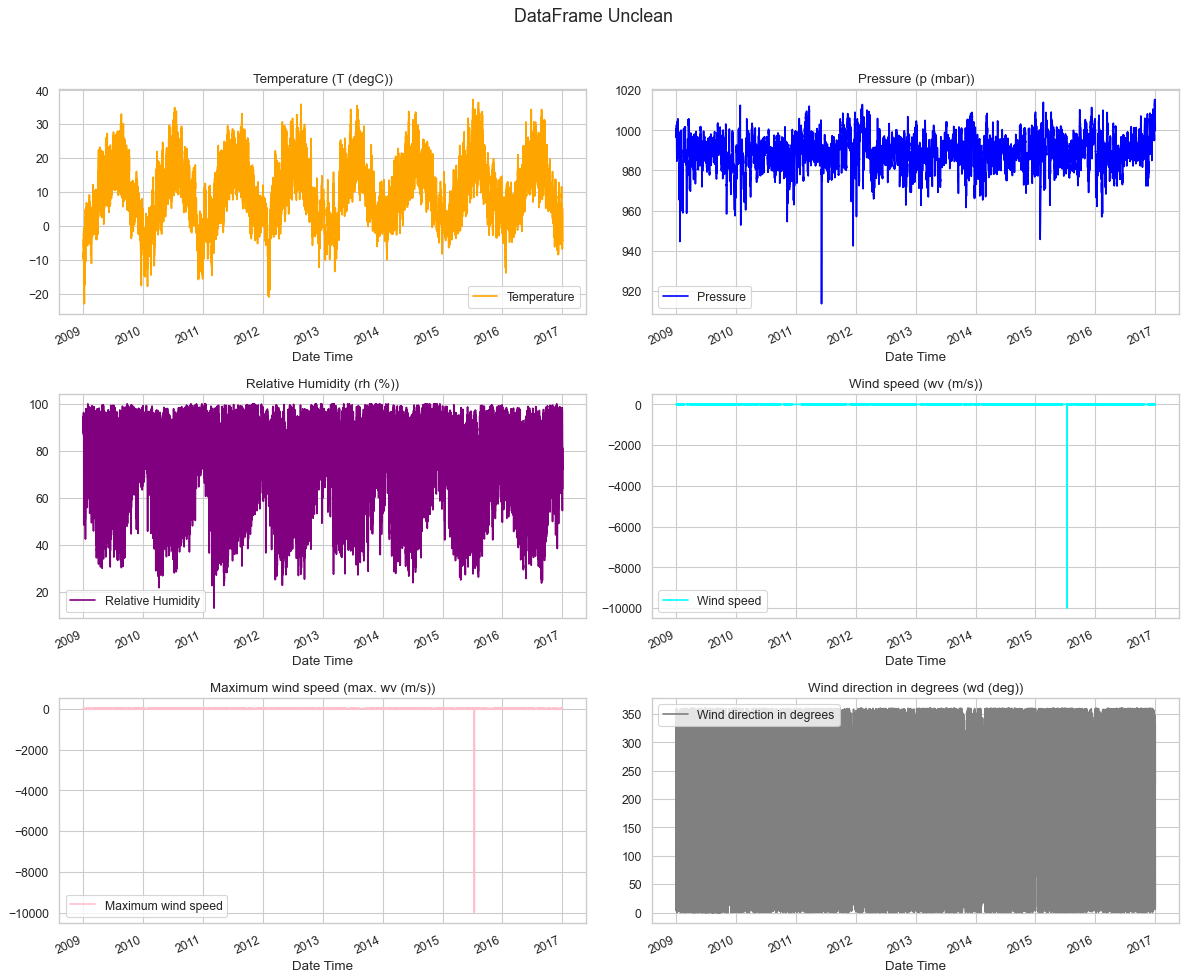

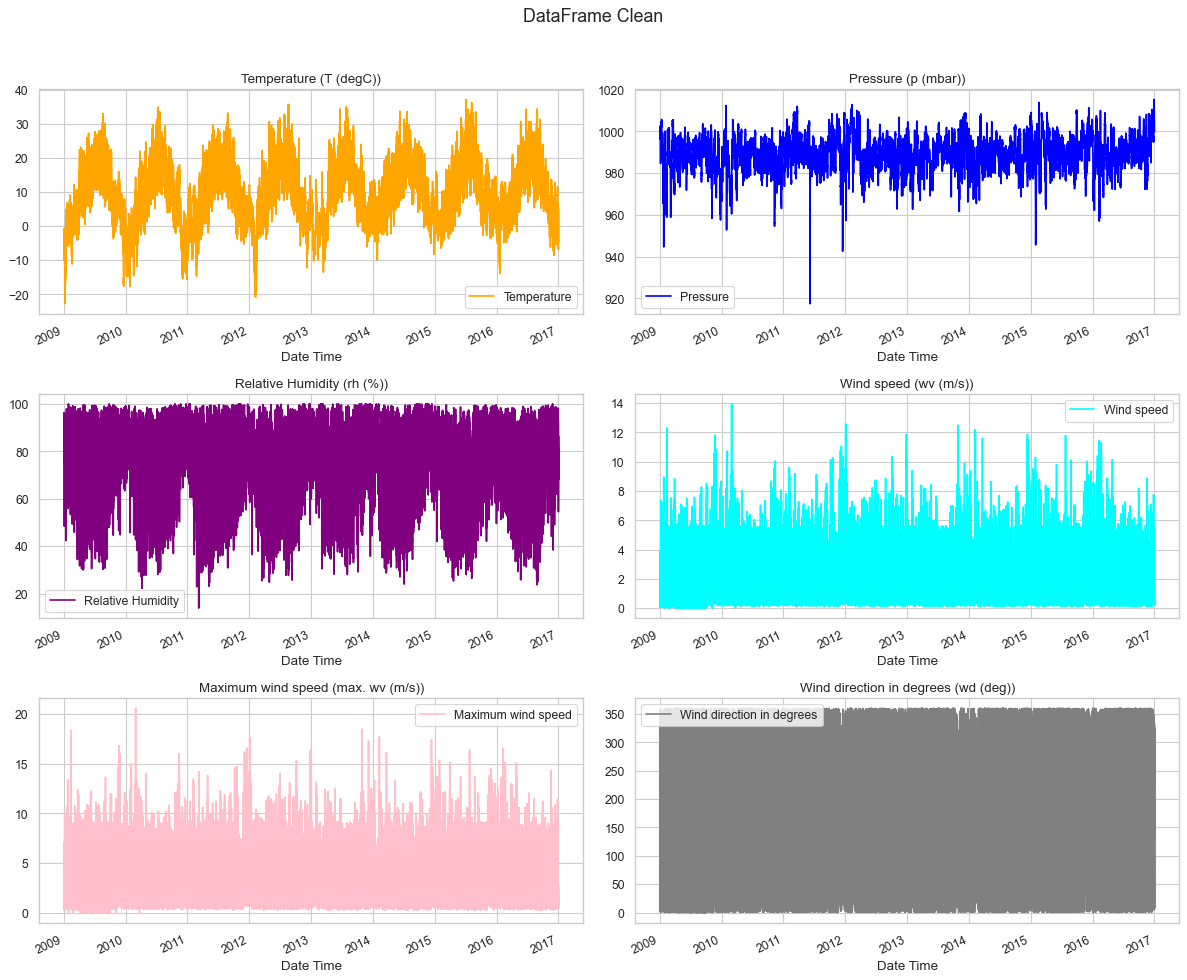

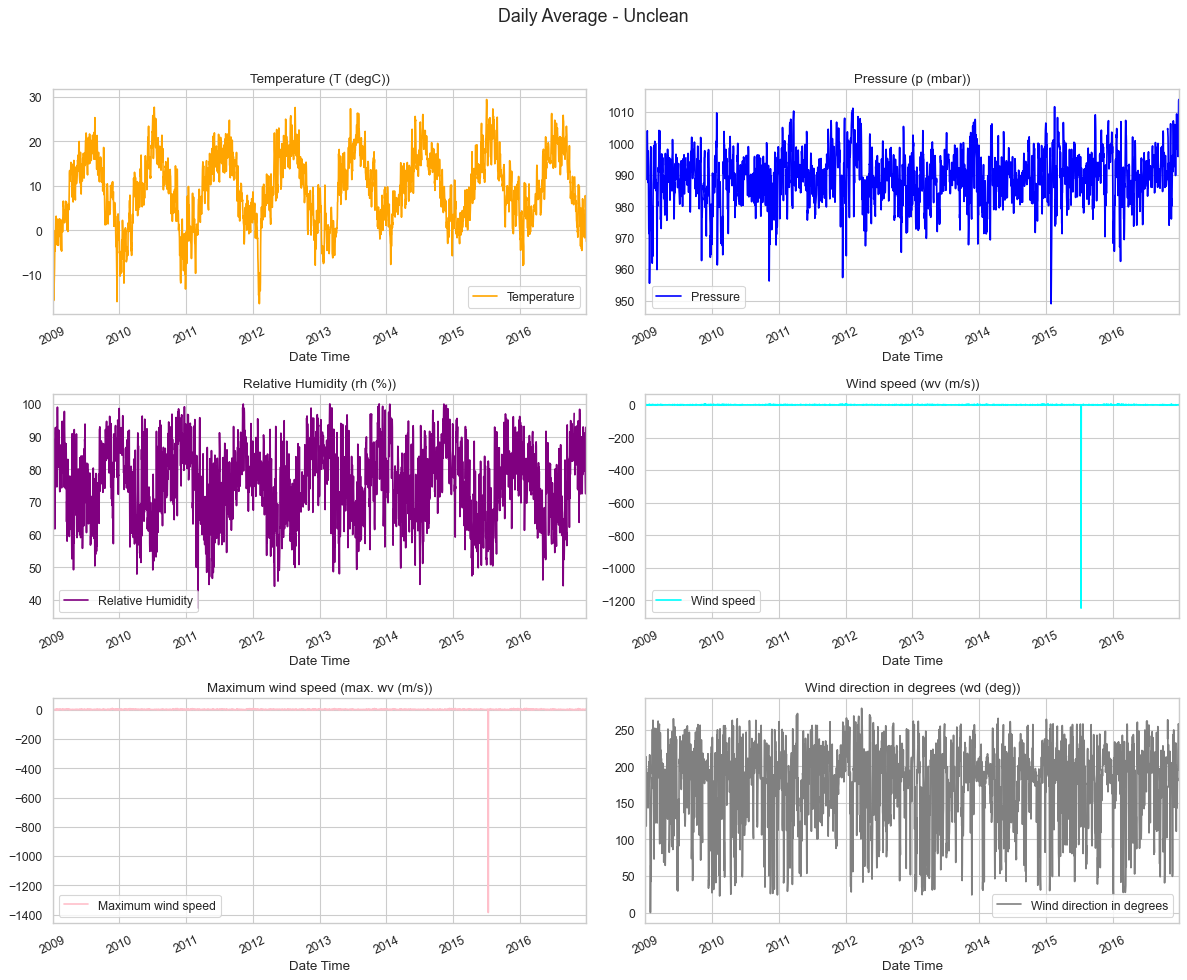

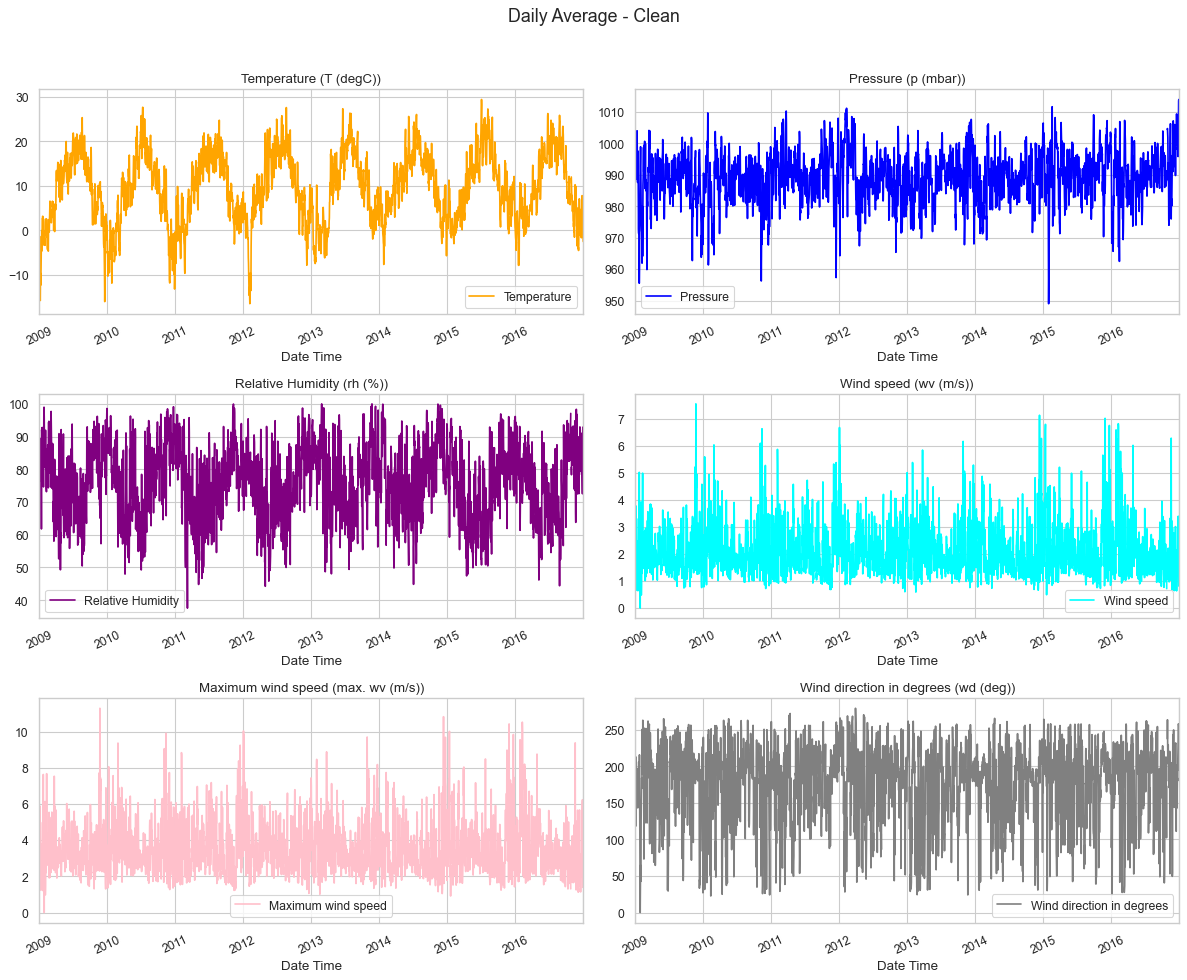

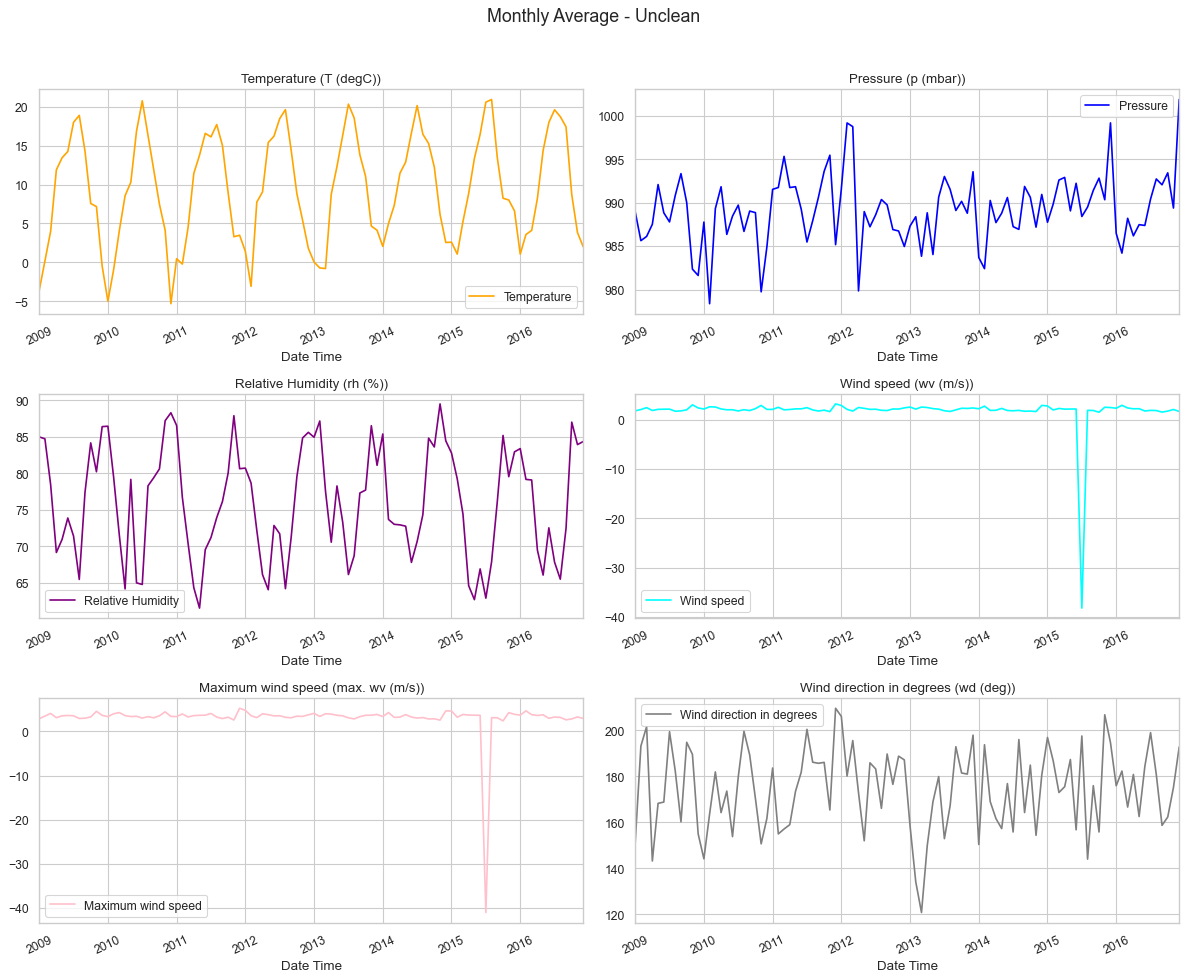

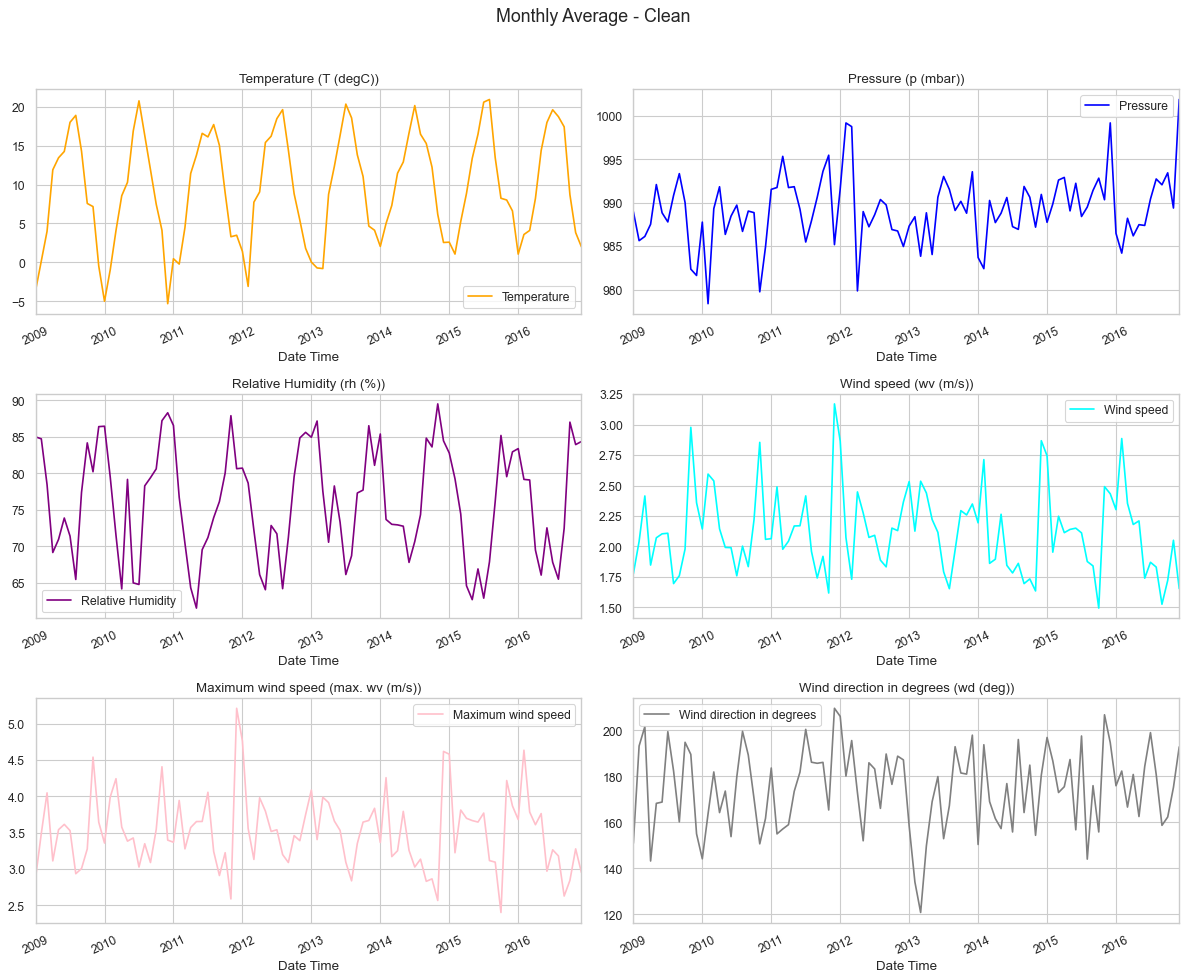

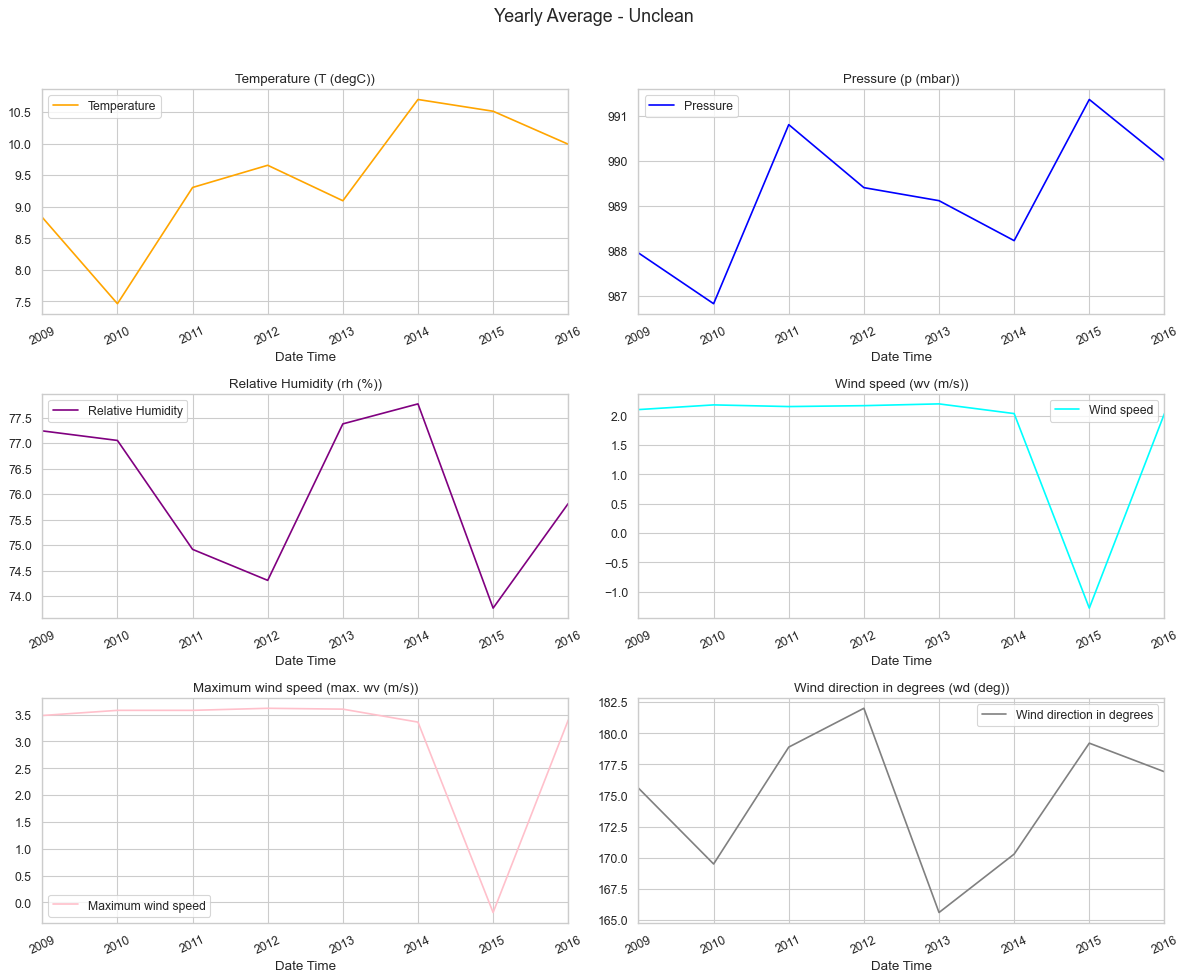

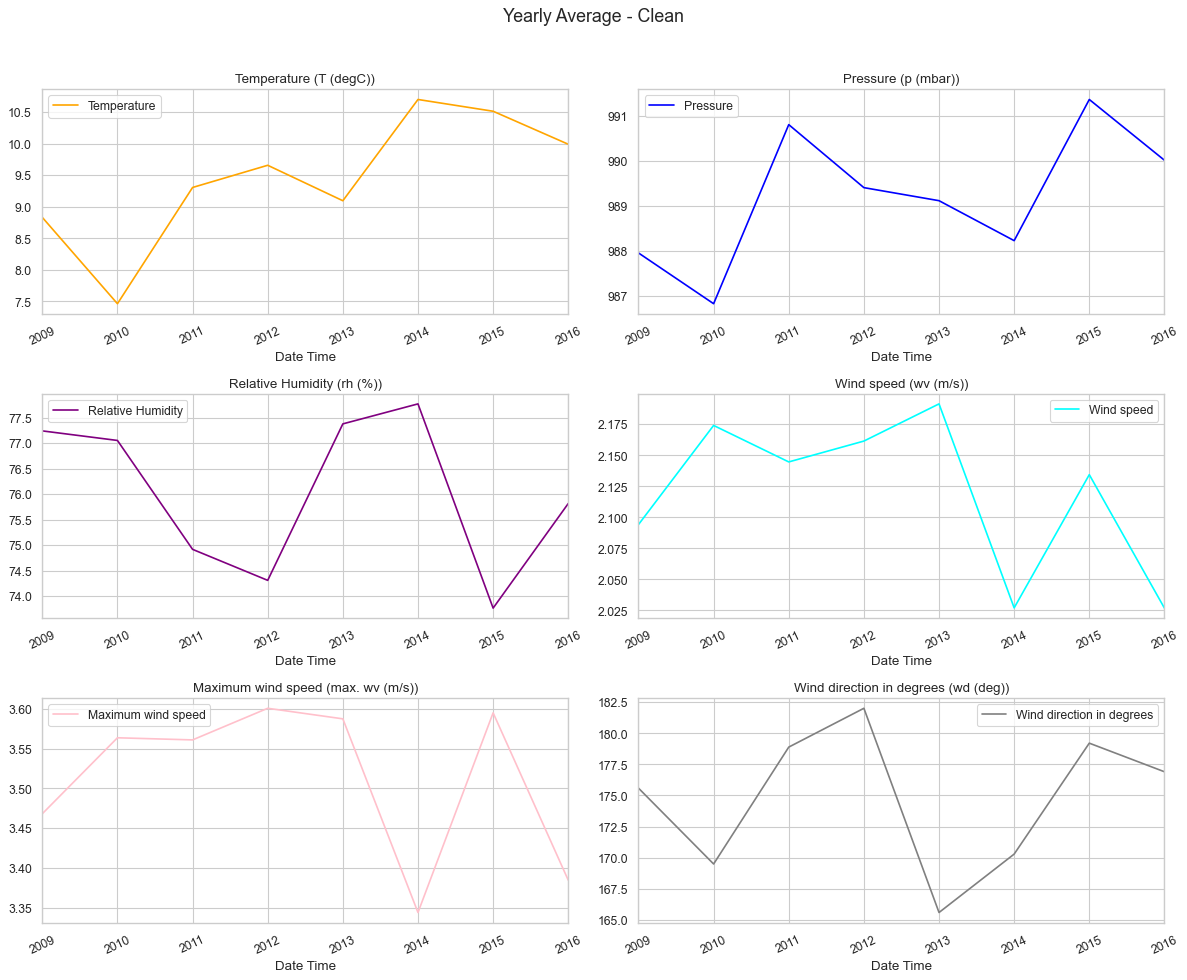

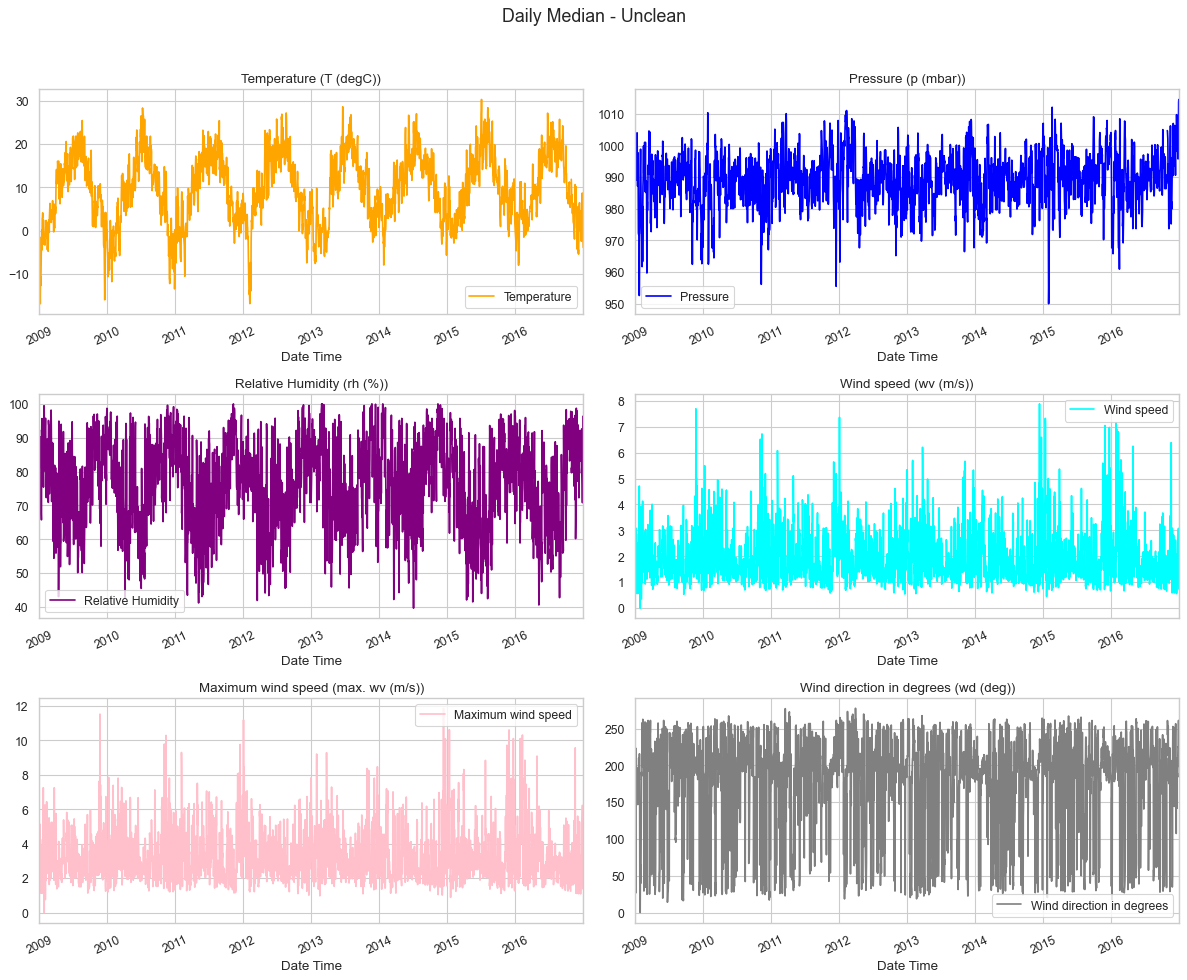

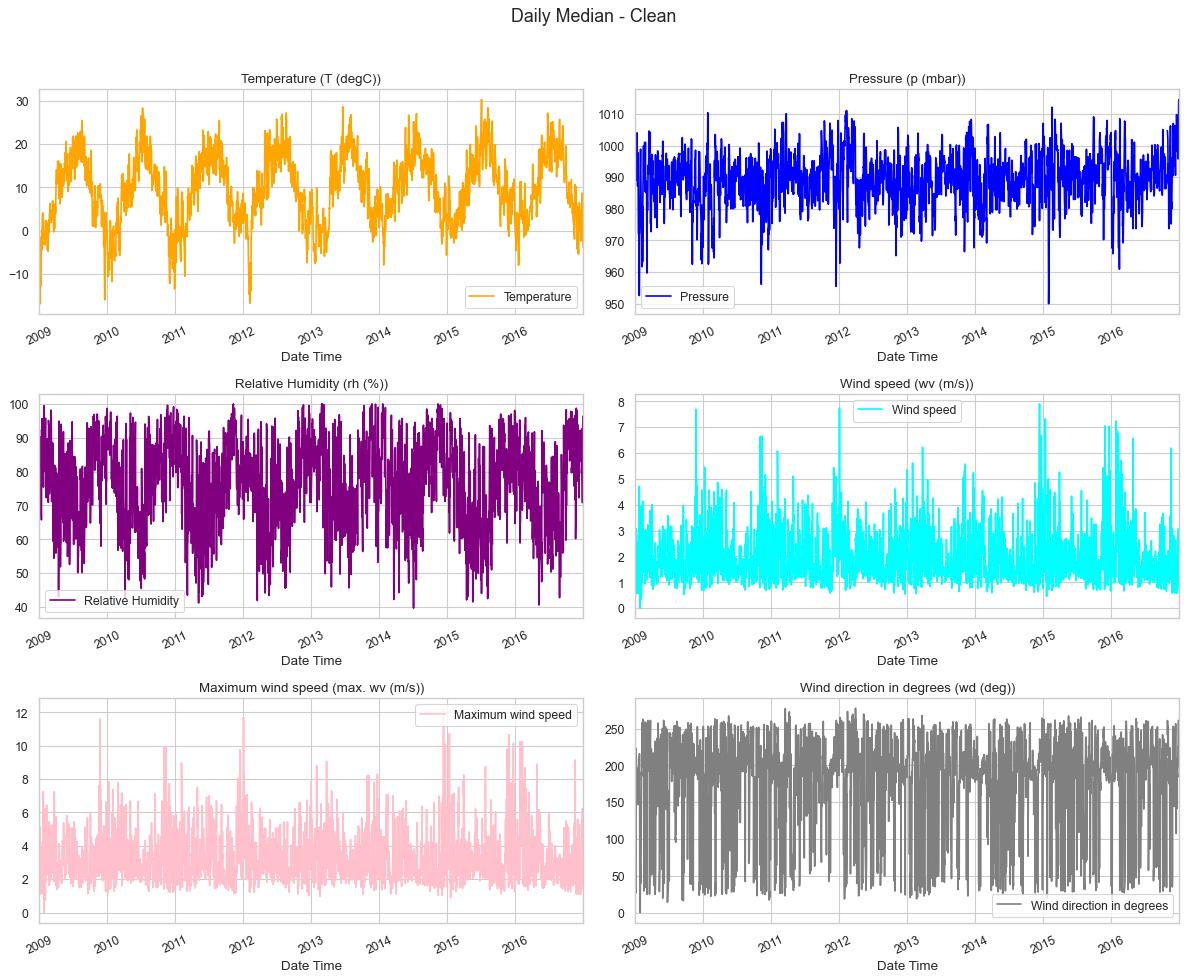

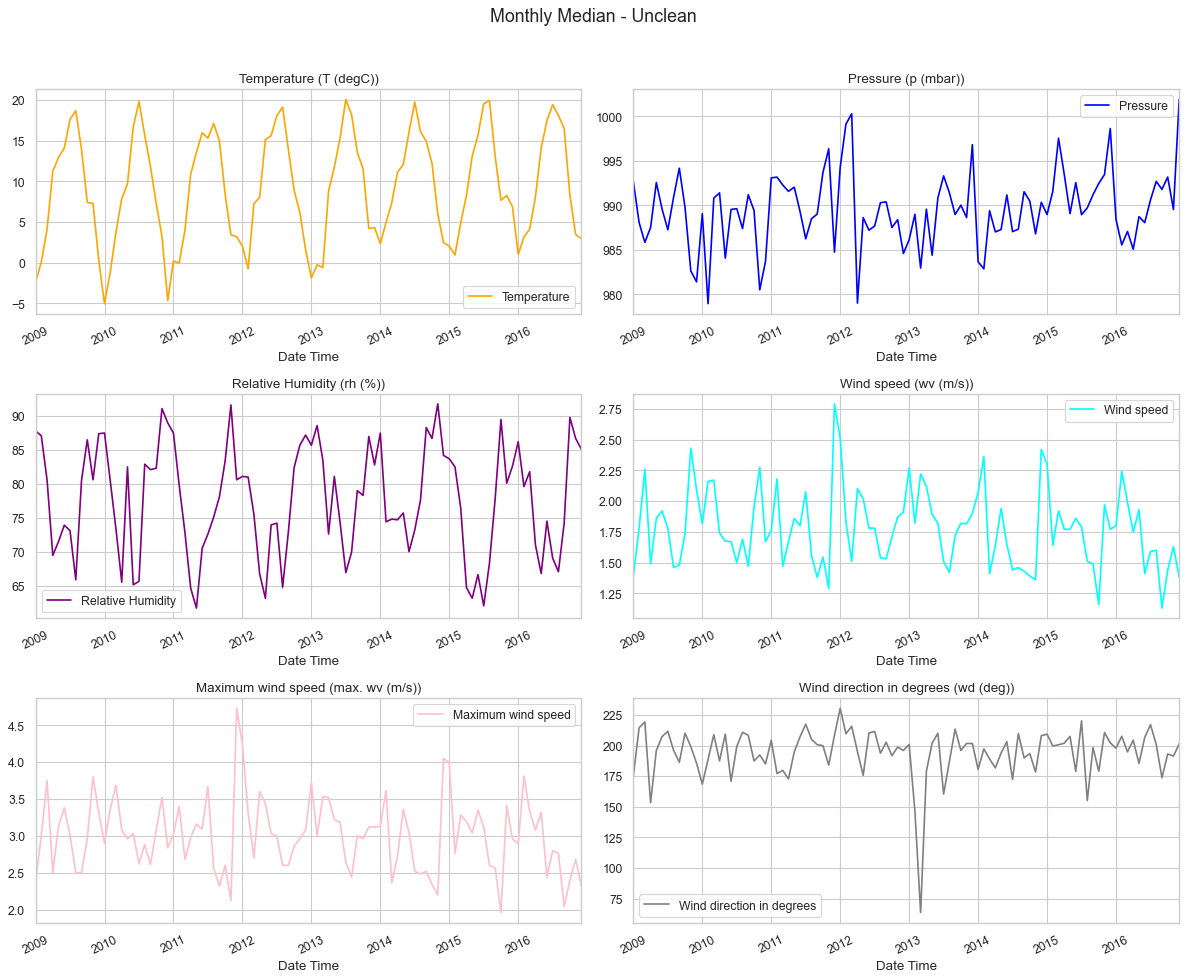

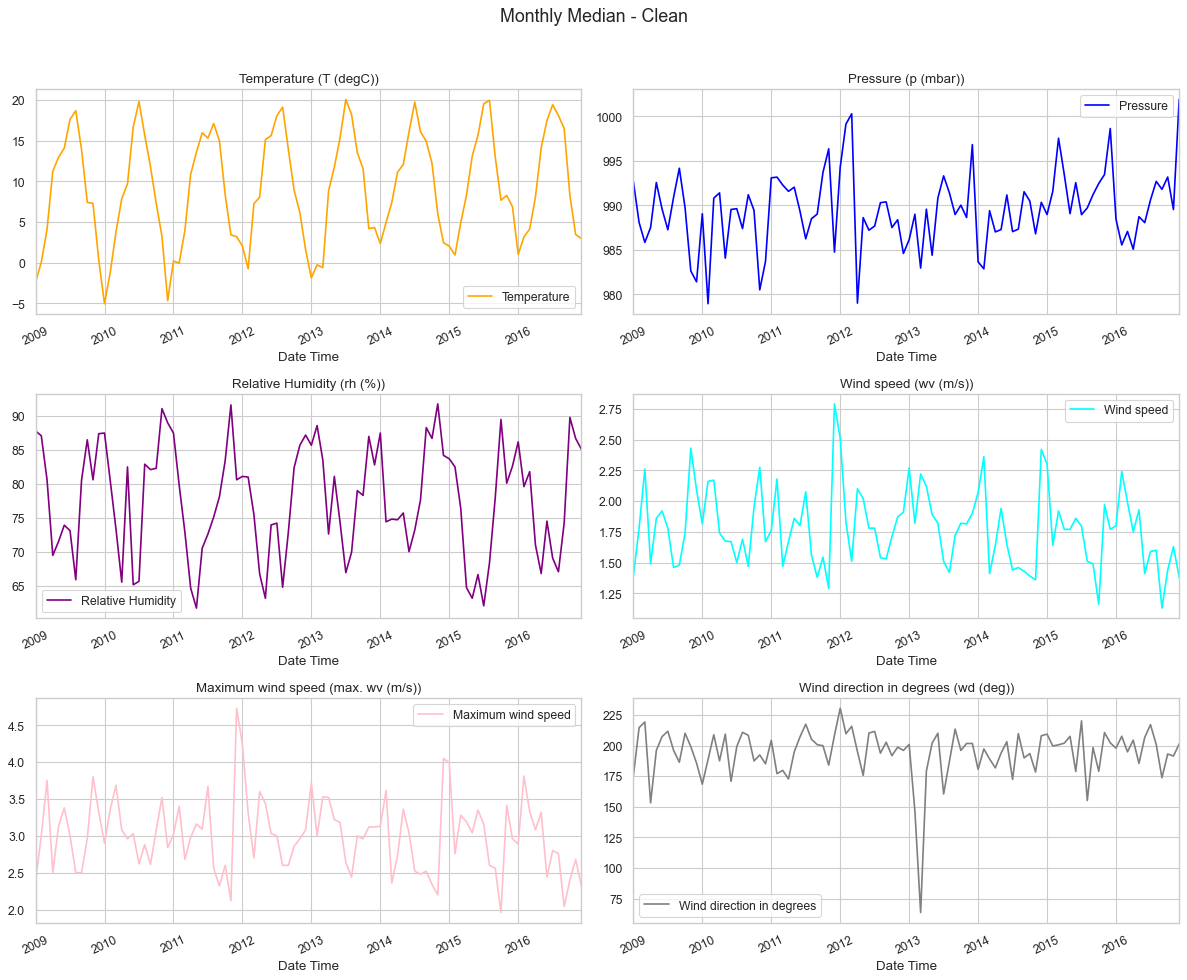

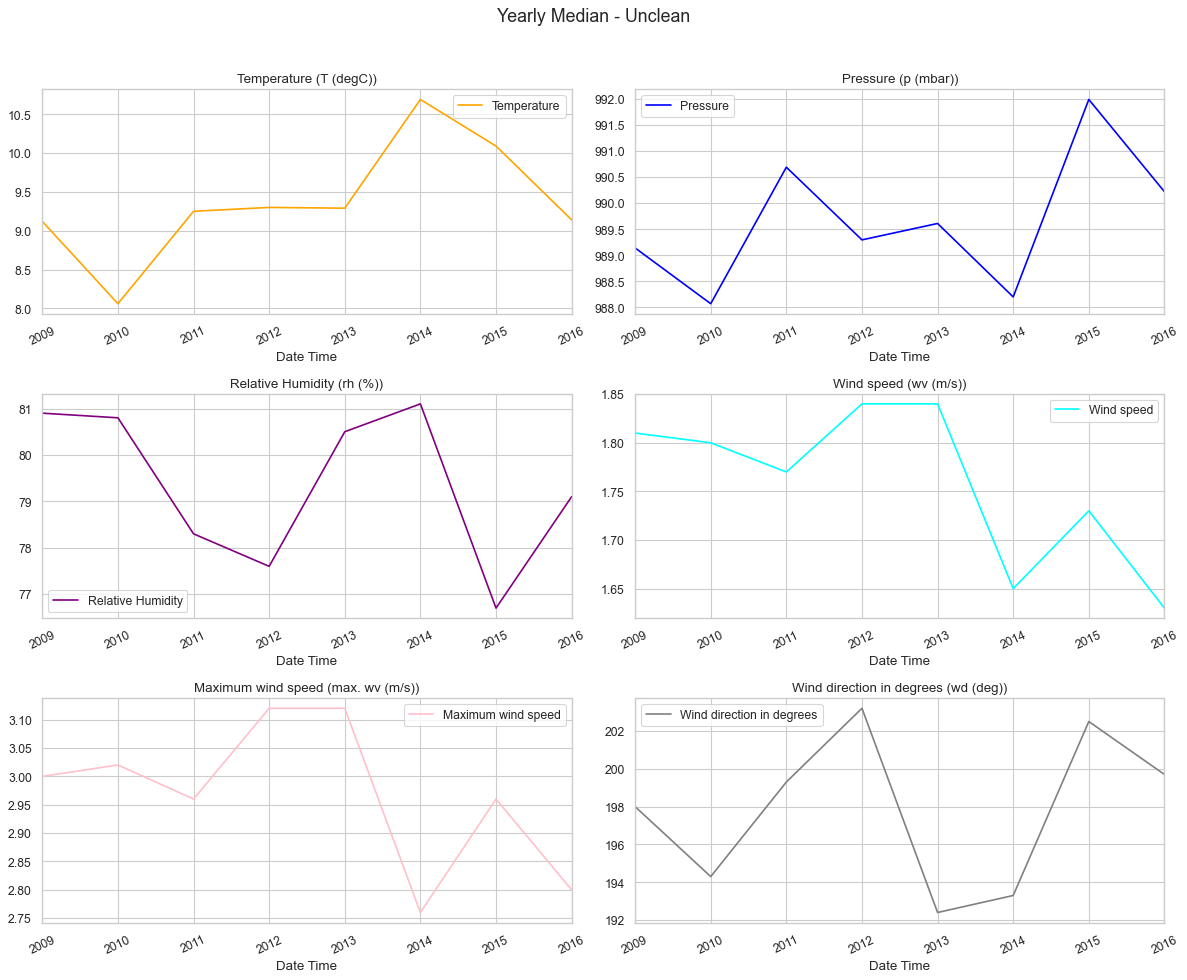

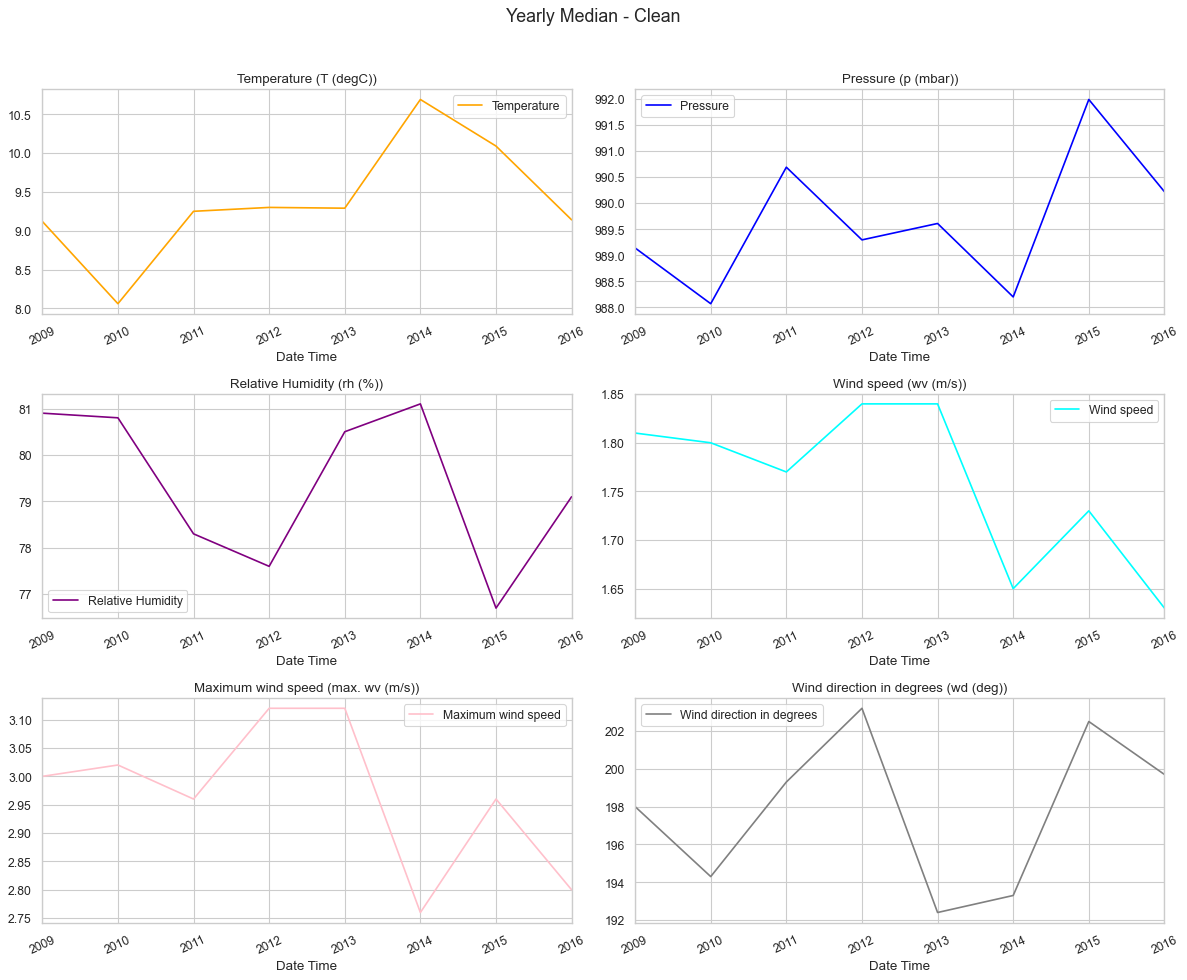

In [14]:
# Raw
show_raw_visualization(df, cols_dict, date_time_key, "DataFrame Unclean")
show_raw_visualization(df_clean, cols_dict, date_time_key, "DataFrame Clean")

# Daily Average
show_raw_visualization(df_day_average, cols_dict, date_time_key, "Daily Average - Unclean")
show_raw_visualization(df_clean_day_average, cols_dict, date_time_key, "Daily Average - Clean")

# Monthly Average
show_raw_visualization(df_month_average, cols_dict, date_time_key, "Monthly Average - Unclean")
show_raw_visualization(df_clean_month_average, cols_dict, date_time_key, "Monthly Average - Clean")

# Yearly Average
show_raw_visualization(df_year_average, cols_dict, date_time_key, "Yearly Average - Unclean")
show_raw_visualization(df_clean_year_average, cols_dict, date_time_key, "Yearly Average - Clean")


# Daily Median
show_raw_visualization(df_day_median, cols_dict, date_time_key, "Daily Median - Unclean")
show_raw_visualization(df_clean_day_median, cols_dict, date_time_key, "Daily Median - Clean")

# Monthly Median
show_raw_visualization(df_month_median, cols_dict, date_time_key, "Monthly Median - Unclean")
show_raw_visualization(df_clean_month_median, cols_dict, date_time_key, "Monthly Median - Clean")

# Yearly Median
show_raw_visualization(df_year_median, cols_dict, date_time_key, "Yearly Median - Unclean")
show_raw_visualization(df_clean_year_median, cols_dict, date_time_key, "Yearly Median - Clean")

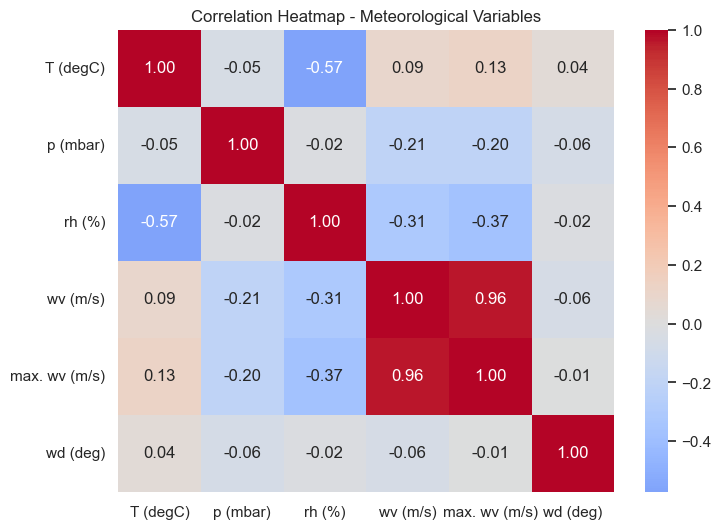

In [15]:
def show_correlation_heatmap(df, cols_dict, title="Correlation Heatmap - Meteorological Variables"):
    """
    Mostra um heatmap de correlação entre todas as variáveis numéricas do cols_dict,
    excluindo a coluna 'Date Time'.
    
    Parâmetros:
    - df: DataFrame com os dados (ex: df_dict["df_clean"])
    - cols_dict: dicionário com metadados das colunas
    - title: título do gráfico
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Seleciona apenas colunas numéricas de interesse
    feature_cols = [col for col in cols_dict if col != 'Date Time']
    
    # Calcula matriz de correlação
    corr_matrix = df[feature_cols].corr()
    
    # Plot heatmap
    plt.figure(figsize=(8,6))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title(title)
    plt.show()

# Mostrar heatmap
show_correlation_heatmap(df_clean, cols_dict)

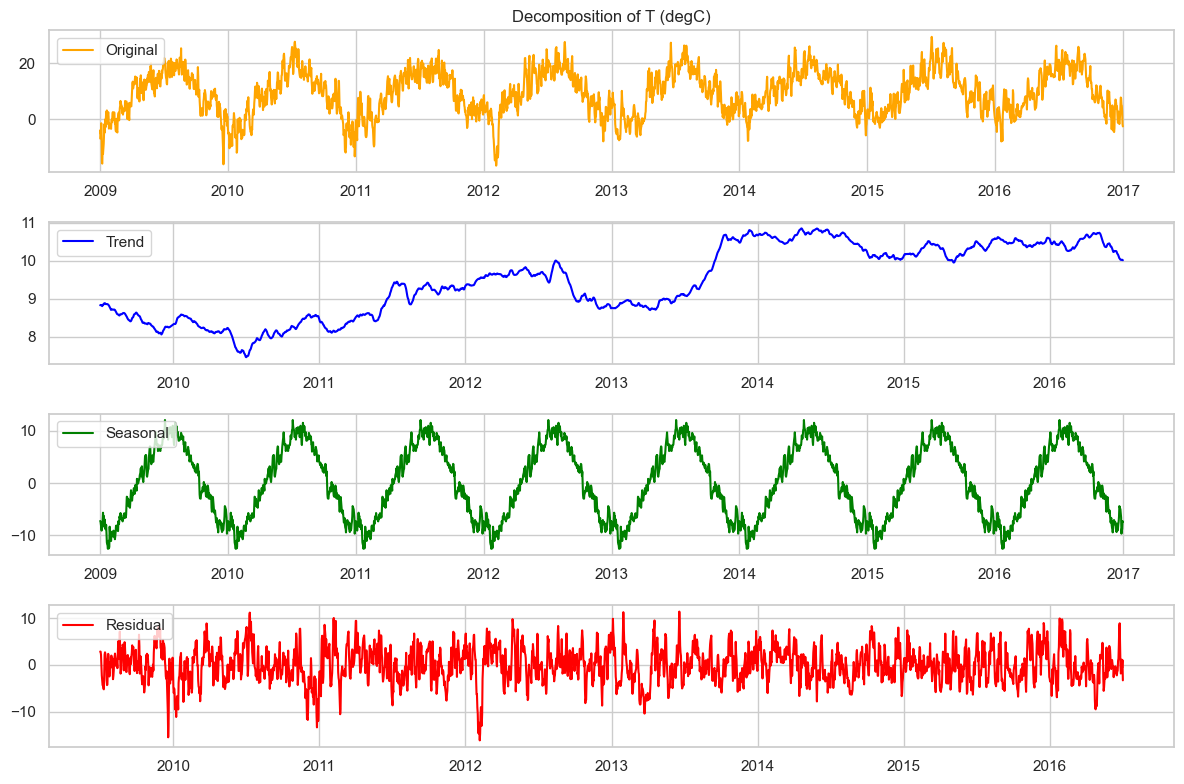

In [16]:
def show_decompose(df, col_name, cols_dict, freq='D', period=365):
    """
    Decompõe uma série temporal em trend, seasonal e residual e plota os gráficos.
    
    Parâmetros:
    - df: DataFrame contendo a coluna de interesse
    - col_name: nome da coluna para decomposição
    - cols_dict: dicionário com metadados (cores, limites, títulos)
    - freq: frequência para resample (default='D' para diário)
    - period: período da sazonalidade (default=365)
    """
    from statsmodels.tsa.seasonal import seasonal_decompose
    import matplotlib.pyplot as plt
    
    # Seleciona série temporal
    ts = df.set_index('Date Time')[col_name].resample(freq).mean()
    
    # Preenche valores ausentes
    ts = ts.interpolate(method='linear')
    
    # Decomposição aditiva
    decomposition = seasonal_decompose(ts, model='additive', period=period)
    
    trend = decomposition.trend
    seasonal = decomposition.seasonal
    residual = decomposition.resid
    
    # Cores da coluna a partir do cols_dict
    color_col = cols_dict[col_name]['color'] if col_name in cols_dict else 'black'
    
    # Plot
    plt.figure(figsize=(12,8))
    
    plt.subplot(4,1,1)
    plt.plot(ts, label='Original', color=color_col)
    plt.title(f"Decomposition of {col_name}")
    plt.legend(loc='upper left')
    
    plt.subplot(4,1,2)
    plt.plot(trend, label='Trend', color='blue')
    plt.legend(loc='upper left')
    
    plt.subplot(4,1,3)
    plt.plot(seasonal, label='Seasonal', color='green')
    plt.legend(loc='upper left')
    
    plt.subplot(4,1,4)
    plt.plot(residual, label='Residual', color='red')
    plt.legend(loc='upper left')
    
    plt.tight_layout()
    plt.show()

# Decomposição da temperatura
show_decompose(df_clean, 'T (degC)', cols_dict, freq='D', period=365)

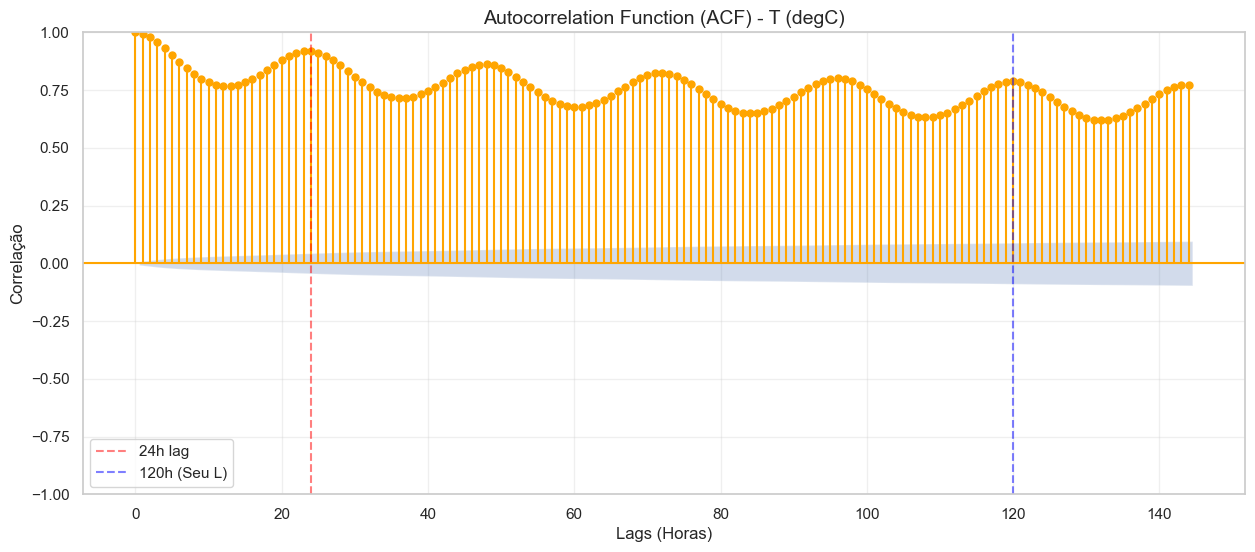

In [17]:
def perform_lag_analysis(df, column='T (degC)', resample_freq='h', lags=144):
    """
    Analisa a autocorrelação da série temporal para justificar o Lookback (L).
    144 lags em resolução horária = 6 dias de análise.
    """
    # 1. Resample para garantir que estamos olhando para horas (conforme o enunciado 3.2)
    series = df.set_index('Date Time')[column].resample(resample_freq).mean().dropna()
    
    # 2. Plot
    plt.figure(figsize=(15, 6))
    plot_acf(series, lags=lags, ax=plt.gca(), color='orange', vlines_kwargs={"colors": 'orange'})
    
    # Customização para facilitar a leitura do relatório
    plt.title(f"Autocorrelation Function (ACF) - {column}", fontsize=14)
    plt.xlabel("Lags (Horas)")
    plt.ylabel("Correlação")
    plt.axvline(x=24, color='red', linestyle='--', alpha=0.5, label='24h lag')
    plt.axvline(x=120, color='blue', linestyle='--', alpha=0.5, label='120h (Seu L)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

perform_lag_analysis(df_dict["df_clean"])

In [18]:
def show_visualization_with_limits(df, cols_dict, date_time_key="Date Time"):
    """
    Visualização das séries temporais com:
    - Faixa realista baseada nos limites definidos em cols_dict
    - Outliers IQR marcados em vermelho
    
    Parâmetros:
    - df: DataFrame com os dados
    - cols_dict: dicionário com metadados das colunas (title, color, limit)
    - date_time_key: coluna de datas (default: "Date Time")
    """
    feature_keys = [col for col in cols_dict if col != date_time_key]
    
    n_plots = len(feature_keys)
    ncols = 2
    nrows = math.ceil(n_plots / ncols)
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows*4), dpi=80)
    axes = axes.flatten()
    
    for i, key in enumerate(feature_keys):
        ax = axes[i]
        col_info = cols_dict[key]
        t_data = df[key]
        time_data = df[date_time_key]
        
        # Plot da série principal
        sns.lineplot(x=time_data, y=t_data, ax=ax, color=col_info.get("color", "black"), label="Series")
        
        # Plot faixa de limite realista (verde)
        if col_info.get("limit") is not None:
            lower, upper = col_info["limit"]
            ax.axhspan(lower, upper, color="green", alpha=0.2, label="Realistic range")
        
        # Marcação de outliers IQR
        Q1 = t_data.quantile(0.25)
        Q3 = t_data.quantile(0.75)
        IQR = Q3 - Q1
        mask_iqr = (t_data < Q1 - 1.5*IQR) | (t_data > Q3 + 1.5*IQR)
        ax.scatter(time_data[mask_iqr], t_data[mask_iqr], color="red", s=10, label="IQR Outliers")
        
        ax.set_title(f"{col_info.get('title', key)} - {key}")
        ax.set_xlabel("Date")
        ax.set_ylabel(key)
        ax.legend()
    
    # Remover eixos extras se houver
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

# 7 min em média 
#show_visualization_with_limits(df, cols_dict)

In [19]:
# Print all DataFrame names stored in df_dict
print("DataFrames in df_dict:")
for name in df_dict.keys():
    print("-", name)

DataFrames in df_dict:
- df_unclean
- df_clean
- df_day_average
- df_clean_day_average
- df_month_average
- df_clean_month_average
- df_year_average
- df_clean_year_average
- df_day_median
- df_clean_day_median
- df_month_median
- df_clean_month_median
- df_year_median
- df_clean_year_median


## 4. Train

### 4.1 Setup

In [20]:
# Select which version of the DataFrame to use for training
DF_VERSION = "df_unclean"
df = df_dict[DF_VERSION].copy()

# ------------------------------
# Lookback and Horizon Parameters
# ------------------------------
L = 120           # Lookback (previous steps)
H = 24            # Prediction horizon
RESAMPLE = 'h'    # Resampling frequency ('h' = hourly)

# ------------------------------
# Model Hyperparameters
# ------------------------------
HIDDEN_DIM = 64
N_LAYERS = 2
N_HEADS = 4        # Only for Transformer

# ------------------------------
# Feature Columns
# ------------------------------
# Remove original date/time and wind direction
METEO_COLS = [col for col in cols_dict.keys() if col not in [date_time_key, 'wd (deg)']]

# Add cyclic time and wind features
CYCLIC_COLS = ['day_sin', 'day_cos', 'year_sin', 'year_cos', 'wd_sin', 'wd_cos']

FEATURE_COLS = METEO_COLS + CYCLIC_COLS
TARGET_COL = 'T (degC)'
N_FEATURES = len(FEATURE_COLS)
TARGET_IDX = FEATURE_COLS.index(TARGET_COL)

# ------------------------------
# Training
# ------------------------------
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 50
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Selected DataFrame for training: {DF_VERSION} -> {df.shape}")
print(f"Number of features: {N_FEATURES}, Target index: {TARGET_IDX}")

Selected DataFrame for training: df_unclean -> (420223, 7)
Number of features: 11, Target index: 0


In [21]:
def apply_cyclic_features(df):
    """
    Transform time and wind direction into cyclical (sin/cos) features.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame with 'Date Time' and 'wd (deg)' columns
    
    Returns:
        pd.DataFrame: DataFrame with added cyclical features
    """
    df = df.copy()
    
    # Ensure 'Date Time' is datetime type
    df[date_time_key] = pd.to_datetime(df[date_time_key])
    ts_s = df[date_time_key].map(pd.Timestamp.timestamp)
    
    # Daily and yearly cycles
    day_sec = 24 * 60 * 60
    year_sec = 365.2425 * day_sec
    
    df['day_sin'] = np.sin(ts_s * (2 * np.pi / day_sec))
    df['day_cos'] = np.cos(ts_s * (2 * np.pi / day_sec))
    df['year_sin'] = np.sin(ts_s * (2 * np.pi / year_sec))
    df['year_cos'] = np.cos(ts_s * (2 * np.pi / year_sec))
    
    # Wind direction cycle
    wd_rad = df['wd (deg)'] * np.pi / 180
    df['wd_sin'] = np.sin(wd_rad)
    df['wd_cos'] = np.cos(wd_rad)
    
    return df

def prepare_training_data(df, resample_freq, L, H, target_idx):
    """
    Prepares sequences and normalizes features for training/validation/testing.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame (cleaned or uncleaned)
        resample_freq (str): Frequency for resampling ('h' = hourly)
        L (int): Lookback window (number of past steps)
        H (int): Forecast horizon (number of steps to predict)
        target_idx (int): Index of target variable in FEATURE_COLS
    
    Returns:
        X_train, y_train, X_val, y_val, X_test, y_test, scaler
    """
    # 1. Resample to desired frequency
    df_resampled = df.set_index(date_time_key).resample(resample_freq).mean().dropna().reset_index()
    
    # 2. Apply cyclical features
    df_final = apply_cyclic_features(df_resampled)
    
    # 3. Chronological split: 70% train, 15% val, 15% test
    n = len(df_final)
    train_df = df_final[:int(n*0.7)]
    val_df = df_final[int(n*0.7):int(n*0.85)]
    test_df = df_final[int(n*0.85):]
    
    # 4. Feature normalization (fit only on training data)
    scaler = StandardScaler()
    train_data = scaler.fit_transform(train_df[FEATURE_COLS])
    val_data = scaler.transform(val_df[FEATURE_COLS])
    test_data = scaler.transform(test_df[FEATURE_COLS])
    
    # 5. Create sequences for LSTM/GRU/Transformer
    def create_sequences(data, L, H, target_idx):
        X, y = [], []
        for i in range(len(data) - L - H + 1):
            X.append(data[i:i+L])
            y.append(data[i+L:i+L+H, target_idx])
        return torch.tensor(np.array(X), dtype=torch.float32), \
               torch.tensor(np.array(y), dtype=torch.float32)
    
    X_train, y_train = create_sequences(train_data, L, H, target_idx)
    X_val, y_val = create_sequences(val_data, L, H, target_idx)
    X_test, y_test = create_sequences(test_data, L, H, target_idx)
    
    return X_train, y_train, X_val, y_val, X_test, y_test, scaler

# ------------------------------
# Prepare data for model
# ------------------------------
X_train, y_train, X_val, y_val, X_test, y_test, dataset_scaler = prepare_training_data(
    df, RESAMPLE, L, H, TARGET_IDX
)

In [22]:
# ------------------------------
# Create DataLoaders
# ------------------------------
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of batches (Train): {len(train_loader)}")
print(f"X_train shape: {X_train.shape} -> [Samples, Seq_Length, Features]")
print(f"y_train shape: {y_train.shape} -> [Samples, Horizon]")

class EarlyStopping:
    """
    Early stops the training if validation loss doesn't improve after a given patience.
    
    Parameters:
        patience (int): How long to wait after last improvement.
        min_delta (float): Minimum change in the monitored quantity to qualify as an improvement.
        path (str): Path to save the best model checkpoint.
    """
    def __init__(self, patience=5, min_delta=0, path='checkpoint.pt'):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        """Saves model when validation loss decreases."""
        torch.save(model.state_dict(), self.path)

Number of batches (Train): 764
X_train shape: torch.Size([48885, 120, 11]) -> [Samples, Seq_Length, Features]
y_train shape: torch.Size([48885, 24]) -> [Samples, Horizon]


### 4.2 Models

In [23]:
class GRUForecaster(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim, dropout=0.2):
        super(GRUForecaster, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # GRU layer: batch_first=True to receive input (Batch, Seq, Features)
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, 
                          batch_first=True, dropout=dropout if num_layers > 1 else 0)
        
        # Output layer: maps hidden state to prediction horizon (24h)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        # x shape: (Batch, Seq_Length, Features)
        # out shape: (Batch, Seq_Length, hidden_dim)
        # h_n shape: (num_layers, Batch, hidden_dim)
        out, h_n = self.gru(x)
        
        # Take only the last time step
        last_step = out[:, -1, :] 
        
        # Predict next H steps
        return self.fc(last_step)

# Instantiate GRU model
gru_model = GRUForecaster(N_FEATURES, HIDDEN_DIM, N_LAYERS, H).to(DEVICE)

In [24]:
# ------------------------------
# Transformer Forecaster
# ------------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # x shape: (Batch, Seq_Length, d_model)
        return x + self.pe[:, :x.size(1)]

class TransformerForecaster(nn.Module):
    def __init__(self, input_dim, d_model, nhead, num_layers, output_dim, dropout=0.1):
        super(TransformerForecaster, self).__init__()
        
        # Input projection: transform features into model dimension
        self.encoder_input = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        
        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, 
                                                   dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Output layer
        self.decoder = nn.Linear(d_model, output_dim)
        
    def forward(self, x):
        # 1. Input projection and positional encoding
        x = self.encoder_input(x)  # (Batch, Seq_Length, d_model)
        x = self.pos_encoder(x)
        
        # 2. Global attention via transformer
        x = self.transformer_encoder(x)
        
        # 3. Pooling: mean over sequence dimension (alternative: last step)
        x = x.mean(dim=1) 
        
        # 4. Predict next H steps
        return self.decoder(x)

# Instantiate Transformer model
transformer_model = TransformerForecaster(N_FEATURES, HIDDEN_DIM, N_HEADS, N_LAYERS, H).to(DEVICE)

In [25]:
# ------------------------------
# Loss function
# ------------------------------
criterion = nn.MSELoss()  # Mean Squared Error for regression

# ------------------------------
# Optimizers
# ------------------------------
gru_optimizer = optim.Adam(gru_model.parameters(), lr=LEARNING_RATE)
tf_optimizer = optim.Adam(transformer_model.parameters(), lr=LEARNING_RATE)

print(f"Models ready on device: {DEVICE}")

Models ready on device: cuda


### 4.3 Train loop

In [26]:
def train_model(model, train_loader, val_loader, optimizer, criterion, epochs, device, model_name="model"):
    history = {'train_loss': [], 'val_loss': []}
    early_stopping = EarlyStopping(patience=7, path=os.path.join(output_path, f'best_{model_name}.pt'))
    
    print(f"\nStarting training for {model_name}...")
    
    for epoch in range(1, epochs + 1):
        # --- TRAINING ---
        model.train()
        train_losses = []
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            train_losses.append(loss.item())
            
        # --- VALIDATION ---
        model.eval()
        val_losses = []
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                val_losses.append(loss.item())
        
        avg_train_loss = np.mean(train_losses)
        avg_val_loss = np.mean(val_losses)
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        
        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch [{epoch}/{epochs}] - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        
        # Early Stopping
        early_stopping(avg_val_loss, model)
        if early_stopping.early_stop:
            print(f"Early stopping at epoch {epoch}. Restoring best model...")
            model.load_state_dict(torch.load(early_stopping.path))
            break
            
    return history


In [27]:
# ------------------------------
# 1. Train GRU
# ------------------------------
gru_history = train_model(
    gru_model, train_loader, val_loader, 
    gru_optimizer, criterion, EPOCHS, DEVICE, "GRU"
)

# ------------------------------
# 2. Train Transformer
# ------------------------------
transformer_history = train_model(
    transformer_model, train_loader, val_loader, 
    tf_optimizer, criterion, EPOCHS, DEVICE, "Transformer"
)


Starting training for GRU...
Epoch [1/50] - Train Loss: 0.1145 | Val Loss: 0.0807
Epoch [5/50] - Train Loss: 0.0636 | Val Loss: 0.0722
Epoch [10/50] - Train Loss: 0.0405 | Val Loss: 0.0936
Early stopping at epoch 12. Restoring best model...

Starting training for Transformer...


c:\Users\tomfp\miniconda3\envs\TSM\Lib\site-packages\torch\nn\functional.py:5476: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  attn_output = scaled_dot_product_attention(q, k, v, attn_mask, dropout_p, is_causal)


Epoch [1/50] - Train Loss: 0.1152 | Val Loss: 0.2335
Epoch [5/50] - Train Loss: 0.0485 | Val Loss: 0.1590
Epoch [10/50] - Train Loss: 0.0217 | Val Loss: 0.1106
Epoch [15/50] - Train Loss: 0.0144 | Val Loss: 0.1156
Early stopping at epoch 15. Restoring best model...


### 4.4 Visualization

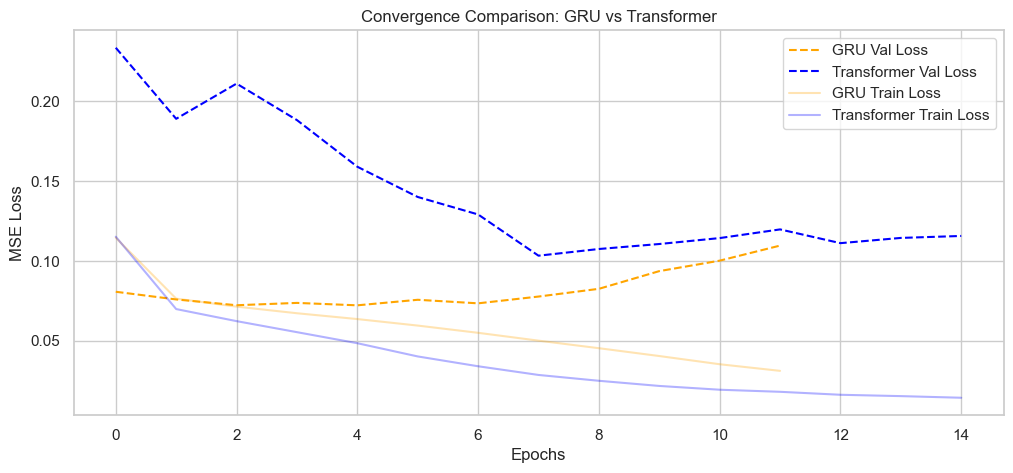

In [28]:
# ------------------------------
# Plot Learning Curves
# ------------------------------
def plot_learning_curves(gru_hist, tf_hist):
    plt.figure(figsize=(12, 5))
    
    # Validation Loss
    plt.plot(gru_hist['val_loss'], label='GRU Val Loss', color='orange', linestyle='--')
    plt.plot(tf_hist['val_loss'], label='Transformer Val Loss', color='blue', linestyle='--')
    
    # Training Loss (faded)
    plt.plot(gru_hist['train_loss'], label='GRU Train Loss', color='orange', alpha=0.3)
    plt.plot(tf_hist['train_loss'], label='Transformer Train Loss', color='blue', alpha=0.3)
    
    plt.title("Convergence Comparison: GRU vs Transformer")
    plt.xlabel("Epochs")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_learning_curves(gru_history, transformer_history)

In [29]:
# ------------------------------
# Evaluate and Denormalize Predictions
# ------------------------------
def evaluate_and_denormalize(model, loader, scaler, target_idx, device):
    model.eval()
    all_preds, all_targets = [], []
    
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            outputs = model(batch_x)
            all_preds.append(outputs.cpu().numpy())
            all_targets.append(batch_y.numpy())
    
    preds_norm = np.concatenate(all_preds, axis=0)
    targets_norm = np.concatenate(all_targets, axis=0)

    # Função auxiliar para inverter normalização
    def invert(data_2d):
        dummy = np.zeros((data_2d.shape[0] * data_2d.shape[1], len(FEATURE_COLS)))
        dummy[:, target_idx] = data_2d.flatten()
        inverted = scaler.inverse_transform(dummy)[:, target_idx]
        return inverted.reshape(data_2d.shape)

    return invert(preds_norm), invert(targets_norm)

# ------------------------------
# Generate Test Set Predictions
# ------------------------------
gru_preds, targets = evaluate_and_denormalize(gru_model, test_loader, dataset_scaler, TARGET_IDX, DEVICE)
tf_preds, _ = evaluate_and_denormalize(transformer_model, test_loader, dataset_scaler, TARGET_IDX, DEVICE)



In [30]:
# ------------------------------
# Compute Performance Metrics
# ------------------------------
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true.flatten(), y_pred.flatten())
    return mae, rmse, r2

gru_metrics = calculate_metrics(targets, gru_preds)
tf_metrics = calculate_metrics(targets, tf_preds)

metrics_df = pd.DataFrame({
    'Metric': ['MAE (°C)', 'RMSE (°C)', 'R² Score'],
    'GRU': gru_metrics,
    'Transformer': tf_metrics
})

print("Comparative Performance Table (Test Set):")
display(metrics_df)

Comparative Performance Table (Test Set):


,Metric,GRU,Transformer
0,MAE (°C),1.669433,1.971091
1,RMSE (°C),2.220339,2.611897
2,R² Score,0.919237,0.888240


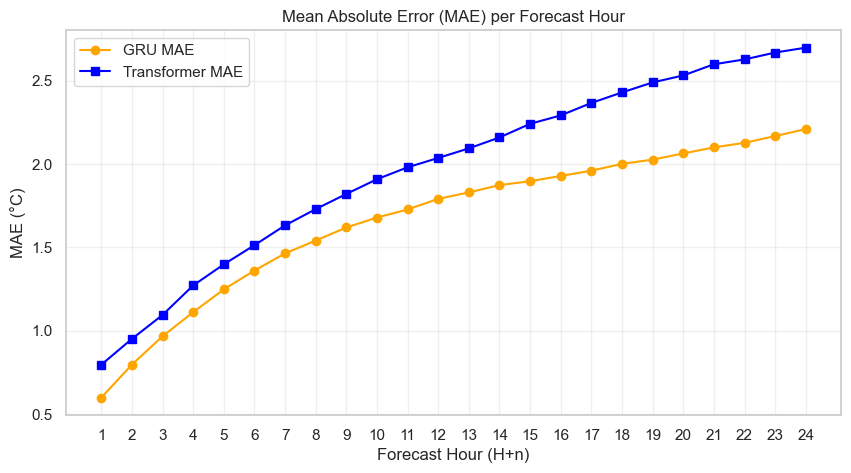

In [31]:
# ------------------------------
# Plot Error over Prediction Horizon
# ------------------------------
def plot_error_over_horizon(y_true, gru_pred, tf_pred):
    gru_mae_per_hour = [mean_absolute_error(y_true[:, i], gru_pred[:, i]) for i in range(H)]
    tf_mae_per_hour = [mean_absolute_error(y_true[:, i], tf_pred[:, i]) for i in range(H)]
    
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, H+1), gru_mae_per_hour, label='GRU MAE', marker='o', color='orange')
    plt.plot(range(1, H+1), tf_mae_per_hour, label='Transformer MAE', marker='s', color='blue')
    
    plt.title("Mean Absolute Error (MAE) per Forecast Hour")
    plt.xlabel("Forecast Hour (H+n)")
    plt.ylabel("MAE (°C)")
    plt.xticks(range(1, H+1))
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_error_over_horizon(targets, gru_preds, tf_preds)

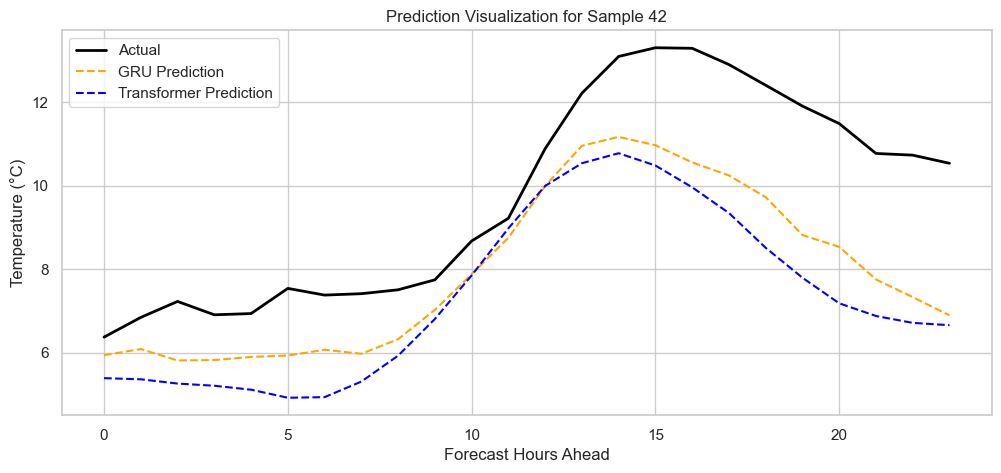

In [32]:
# ------------------------------
# Plot Single Sample Prediction
# ------------------------------
def plot_sample_prediction(y_true, gru_pred, tf_pred, sample_idx=0):
    plt.figure(figsize=(12, 5))
    plt.plot(y_true[sample_idx], label='Actual', color='black', linewidth=2)
    plt.plot(gru_pred[sample_idx], label='GRU Prediction', color='orange', linestyle='--')
    plt.plot(tf_pred[sample_idx], label='Transformer Prediction', color='blue', linestyle='--')
    
    plt.title(f"Prediction Visualization for Sample {sample_idx}")
    plt.xlabel("Forecast Hours Ahead")
    plt.ylabel("Temperature (°C)")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_sample_prediction(targets, gru_preds, tf_preds, sample_idx=42)